# Congress Trading — a quantitative teardown 🔬
### Disclosure-date event study vs calendar-time NW alpha · a 20-seed random-dates placebo (timing vs stock list) · party / size / famous Welch splits · the famous-names clustering autopsy · costs · a synthetic faithful-engine control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Famous_names_beat%3F: Busted](https://img.shields.io/badge/Famous_names_beat%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). Ziobrowski et al. (2004) found senators' purchases beat the market by ~85 bps/mo (1993–98, **transaction-date** entry). The only *replicable* version is the **disclosure-date** trade — and the modern tape (Belmont et al. 2022 agree) says it carries nothing.

> ⚠️ **Data + survivorship note.** Senate Stock Watcher PTR archive: **2,776** stock purchases, disclosures 2015-01-05 → 2021-03-09 (hard stop — the scraper died), 26 senators, Perdue = 39.3% of events. 80% of events resolve on Yahoo with a full 12-mo window; the missing ~20% are delisted/renamed tickers — a **survivor tilt that favours the claim**. One recycled ticker (ITC) dropped by an integrity guard. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (fingerprint `884027dc84c9`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from congress_trading import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PX, SPY, EV = data.load_real()
    ABN = st.event_abnormal(PX, SPY, EV)
else:
    PX = SPY = EV = ABN = None
print("real cache present:", HAVE_REAL,
      "| events:", (0 if EV is None else len(EV)),
      "| tickers:", (0 if PX is None else PX.shape[1]))

# frozen headline numbers (mirror of docs/results.md)
R = {'n_events': 2776, 'n_senators': 26, 'disc_start': '2015-01-05', 'disc_end': '2021-03-09', 'n_R': 1990, 'n_D': 786, 'perdue_share': 39.3, 'famous_n': 1212, 'famous_share': 43.7, 'lag_median': 19, 'lag_mean': 26.3, 'n_tickers': 438, 'n_dropped': 1, 'dropped': 'ITC', 'n_used': 437, 'n_covered': 2221, 'coverage': 80.0, 'bhar': [(63, -0.14, -0.46, 2221), (126, 1.07, 2.33, 2221), (252, 4.87, 6.35, 2221)], 'caltime': [(63, -0.01, -0.0, 1617, 48), (126, 3.72, 1.11, 1680, 80), (252, 2.5, 0.89, 1806, 123)], 'plc_alpha': 3.31, 'plc_alpha_sd': 0.84, 'plc_t': 1.79, 'plc_t_sd': 0.43, 'real_minus_plc': 0.41, 'plc_z': 0.49, 'costs': [(0.0, 3.72, 1.11), (5.0, 3.52, 1.05), (10.0, 3.32, 0.99)], 'splits126': [('R vs D', 1.12, 1553, 0.95, 668, 0.17, 0.18), ('big (>=$15k) vs small', 1.52, 585, 0.91, 1636, 0.6, 0.56), ('famous vs rest', 0.59, 840, 1.36, 1381, -0.77, -0.79)], 'famous252': (9.61, 1.99, 7.61, 4.57), 'famous_ct': (0.09, 0.02), 'boring_ct': (4.66, 1.85), 'exPerdue_ct': (4.75, 1.87), 'syn_null_t': 0.03, 'syn_null_sd': 0.97, 'syn_null_max': 2.1, 'syn_edge_alpha': 27.37, 'syn_edge_t': 12.25, 'fingerprint': '884027dc84c9', 'asof': '2026-07-03'}


real cache present: True | events: 2776 | tickers: 437


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Calendar-time alpha **-0.01 / +3.72 / +2.50 %/yr** at 3/6/12-mo holds, **NW t = -0.00 / +1.11 / +0.89** — never near 2; placebo shows the drift is the stock list (real − placebo = **+0.41%/yr**, +0.49σ). |
| **Tradability** | `MIRAGE` | Median **19-day** disclosure lag; net alpha +3.32%/yr at 10 bps (t = 0.99); survivor-tilted panel *helps* and it still fails. |
| **Famous names beat?** | `BUSTED` | Famous calendar-time alpha **+0.09%/yr (t = 0.02)** vs boring +4.66%/yr (t = 1.85); the pooled famous premium (+7.6 pp at 12 mo, Welch t = 4.6) is an overlap artifact. |

> 💡 In plain words: measured at the only date you can trade, senators' disclosed buys are noise; the +4.9%/12-mo pooled headline is double-counting; and the meme names are where the zero is.

## 1 · The claim, steelmanned

Let event $e$ be a disclosed purchase (senator $s$, ticker $k$, disclosure date $d_e$). Entry is the first close $t_0(e) > d_e$ (exactly one execution lag). The BHAR at horizon $h$ is

$$\mathrm{abn}_h(e) = \frac{P_{k,t_0+h}}{P_{k,t_0}} - \frac{M_{t_0+h}}{M_{t_0}},$$

with $M$ = SPY, both total-return.

- **H₁ (the modern Ziobrowski).** Disclosed purchases carry positive abnormal return: a calendar-time portfolio of them has $\alpha > 0$ with a robust $t \ge 2$.
- **H₂ (timing, not list).** The alpha comes from *when* they trade, not just *which* stocks they hold — i.e. it must beat a same-tickers random-dates placebo.
- **H₃ (the meme).** The famous names (DOJ-probe subset) out-earn the boring aggregate.

We find **H₁ rejected** (max NW t = 1.11), **H₂ rejected** (+0.41%/yr vs placebo, +0.49σ), **H₃ busted** (famous alpha ≈ 0; the pooled contrast is a clustering artifact).

## 2 · So what? — the two statistical traps this dataset sets

**Trap 1: overlapping BHARs.** 2,221 12-month windows drawn from ~6 years of tape are not 2,221 independent observations — especially when one senator (Perdue, 39% of events) files hundreds of buys within months of each other. The pooled naive t treats every window as fresh evidence; Fama (1998) is the classic warning, and the **calendar-time portfolio** (one daily excess-return series, HAC t) is the standard fix — the desk's verdict statistic.

**Trap 2: list vs timing.** An equal-weight basket of senator-held names can beat cap-weighted SPY for reasons that have nothing to do with disclosure dates (size tilt, 2020–21 breadth). The **random-dates placebo** (same tickers, random disclosure days, ≥ 20 seeds per house rule) prices the list; only the *excess over placebo* is timing information.

## 3 · How we'd know — the protocol

- **Events.** 2,776 PTR stock purchases (Senate Stock Watcher per-day reports; the filename carries the disclosure date), 2015-01-05 → 2021-03-09, 26 senators, R 1,990 / D 786.
- **Prices.** yfinance total-return closes, 438 resolvable tickers + SPY; 1 recycled ticker dropped (ITC); coverage 2,221/2,776 = 80% (survivorship named).
- **Execution.** ONE lag: entry at the first close strictly after disclosure. Long-only; no borrow.
- **Color.** Pooled BHAR means at 63/126/252 td with naive t (flagged as overstated).
- **Primary.** Calendar-time EW portfolio (hold = 63/126/252 td), daily excess vs SPY, **Newey-West t (10 lags)**.
- **Placebo.** Same tickers, uniform-random disclosure dates, 20 seeds; report mean ± sd.
- **Splits.** Welch t: party, trade size (≥ $15k), famous (Perdue/Loeffler/Inhofe — the 2020 DOJ-probe names with purchases on this tape).
- **Costs.** 0/5/10 bps one-way × 2 legs amortised over the hold.
- **Control.** Synthetic world with planted post-disclosure drift; null over 20 seeds.

## 4 · The teardown

### 4a · The overlap illusion — pooled BHAR vs calendar-time

The pooled per-event view says +4.87% at 12 months (naive t = 6.35). The calendar-time engine — which cannot double-count a market episode — says t = 0.89. Same tape, same trades: the entire 'significance' was pseudo-replication.

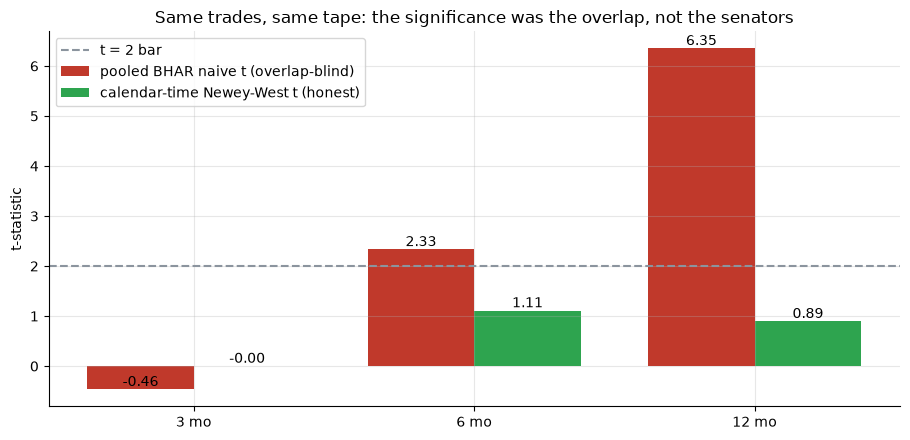

h= 63: pooled -0.14% (naive t=-0.46)  |  calendar-time -0.01%/yr (NW t=-0.00)
h=126: pooled +1.07% (naive t=+2.33)  |  calendar-time +3.72%/yr (NW t=+1.11)
h=252: pooled +4.87% (naive t=+6.35)  |  calendar-time +2.50%/yr (NW t=+0.89)


In [2]:
if HAVE_REAL:
    bh = [(r['h'], r['mean_pct'], r['naive_t']) for r in st.pooled_table(ABN)]
    ct = [(h, *[st.calendar_time(PX, SPY, EV, hold=h)[k] for k in ('alpha_ann_pct', 'nw_t')])
          for h in (63, 126, 252)]
else:
    bh = [(b[0], b[1], b[2]) for b in R['bhar']]
    ct = [(c[0], c[1], c[2]) for c in R['caltime']]
x = np.arange(3); w = .38
fig, ax = plt.subplots(figsize=(9.2, 4.5))
ax.bar(x - w/2, [b[2] for b in bh], w, color=RED, label='pooled BHAR naive t (overlap-blind)')
ax.bar(x + w/2, [c[2] for c in ct], w, color=GREEN, label='calendar-time Newey-West t (honest)')
ax.axhline(2, ls='--', c=GREY, label='t = 2 bar')
for i, b in enumerate(bh): ax.annotate(f'{b[2]:.2f}', (i - w/2, b[2]), ha='center', va='bottom')
for i, c in enumerate(ct): ax.annotate(f'{c[2]:.2f}', (i + w/2, max(c[2], 0)), ha='center', va='bottom')
ax.set_xticks(x); ax.set_xticklabels(['3 mo', '6 mo', '12 mo'])
ax.set_ylabel('t-statistic'); ax.legend()
ax.set_title('Same trades, same tape: the significance was the overlap, not the senators')
plt.tight_layout(); plt.show()
for (h, m, t), (_, a, nt) in zip(bh, ct):
    print(f'h={h:>3}: pooled {m:+.2f}% (naive t={t:+.2f})  |  calendar-time {a:+.2f}%/yr (NW t={nt:+.2f})')

> 💡 In plain words: the red bars are what you get if you pretend 2,221 overlapping windows are independent — *t* = 6.35 at 12 months, a publishable 'anomaly'. The green bars are the same information without double-counting: *t* = 0.89. The gap between red and green **is** the meme.

### 4b · Timing vs stock list — the 20-seed random-dates placebo

Same tickers, same event count, disclosure dates redrawn uniformly on the tape (20 seeds). If the senators' *dates* matter, the real alpha must sit outside the placebo cloud.

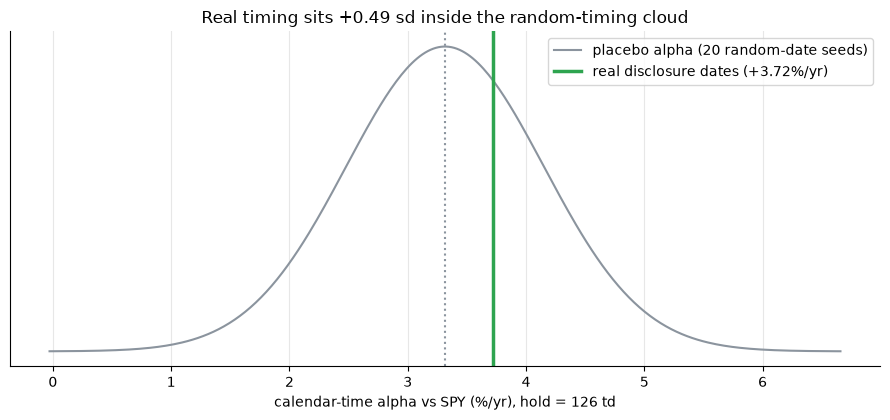

real +3.72%/yr | placebo +3.31 +/- 0.84%/yr | z = +0.49


In [3]:
if HAVE_REAL:
    pl = st.placebo_random_dates(PX, SPY, EV, hold=126, n_seeds=20)
    plc, plc_sd = pl['mean_alpha_ann_pct'], pl['sd_alpha_ann_pct']
    real = st.calendar_time(PX, SPY, EV, hold=126)['alpha_ann_pct']
else:
    plc, plc_sd, real = R['plc_alpha'], R['plc_alpha_sd'], R['caltime'][1][1]
z = (real - plc) / plc_sd
fig, ax = plt.subplots(figsize=(9.0, 4.3))
xs = np.linspace(plc - 4*plc_sd, plc + 4*plc_sd, 300)
ax.plot(xs, np.exp(-((xs - plc)/plc_sd)**2 / 2), c=GREY, label='placebo alpha (20 random-date seeds)')
ax.axvline(plc, c=GREY, ls=':')
ax.axvline(real, c=GREEN, lw=2.5, label=f'real disclosure dates ({real:+.2f}%/yr)')
ax.set_xlabel('calendar-time alpha vs SPY (%/yr), hold = 126 td'); ax.set_yticks([])
ax.set_title(f'Real timing sits {z:+.2f} sd inside the random-timing cloud')
ax.legend(); plt.tight_layout(); plt.show()
print(f'real {real:+.2f}%/yr | placebo {plc:+.2f} +/- {plc_sd:.2f}%/yr | z = {z:+.2f}')

> 💡 In plain words: buying the senators' stocks on **random days** earns **+3.31%/yr** over SPY (their names, equal-weighted, simply beat the cap-weighted index over 2015–22). Their **actual** dates earn **+3.72%/yr** — +0.49σ from the placebo mean. The disclosure dates carry **zero** incremental information. H₂ dead.

### 4c · Splits — party, size (Welch t; color)

The folklore sub-claims: one party trades better; bigger trades mean stronger conviction.

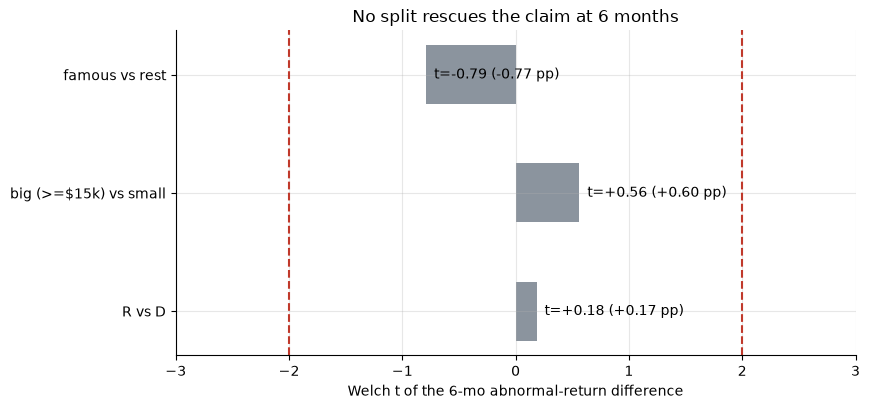

R vs D                   diff +0.17 pp  Welch t = +0.18
big (>=$15k) vs small    diff +0.60 pp  Welch t = +0.56
famous vs rest           diff -0.77 pp  Welch t = -0.79


In [4]:
if HAVE_REAL:
    rows = []
    for label, mask in [('R vs D', ABN['party'] == 'R'),
                        ('big (>=$15k) vs small', ~ABN['amount'].str.startswith('$1,001')),
                        ('famous vs rest', ABN['famous'])]:
        r = st.split_welch(ABN, mask, h=126)
        rows.append((label, r['diff_pct'], r['welch_t']))
else:
    rows = [(s[0], s[5], s[6]) for s in R['splits126']]
fig, ax = plt.subplots(figsize=(8.8, 4.2))
ax.barh([r[0] for r in rows], [r[2] for r in rows], color=GREY, height=.5)
ax.axvline(2, ls='--', c=RED); ax.axvline(-2, ls='--', c=RED)
for i, r in enumerate(rows): ax.annotate(f'  t={r[2]:+.2f} ({r[1]:+.2f} pp)', (r[2], i), va='center')
ax.set_xlim(-3, 3); ax.set_xlabel('Welch t of the 6-mo abnormal-return difference')
ax.set_title('No split rescues the claim at 6 months')
plt.tight_layout(); plt.show()
for r in rows: print(f'{r[0]:24s} diff {r[1]:+.2f} pp  Welch t = {r[2]:+.2f}')

> 💡 In plain words: Republicans vs Democrats: nothing (t = +0.18). Big trades vs small: nothing (t = +0.56). Famous vs rest at 6 months: nothing (t = −0.79 — the famous names are *behind*). Every folklore split is flat where the windows overlap least.

### 4d · The famous-names autopsy (the third axis)

At 12 months the pooled split *explodes*: famous **+9.61%** vs boring +1.99%, Welch **t = +4.57**. A real-tape t ≥ 2! Except: Welch assumes independent observations, and the famous subset is 840 windows from three senators — mostly Perdue's clustered 2019–20 buys, each re-counting the same 2020–21 rebound (the same split is **negative** at 6 months). The calendar-time engine — which fixes exactly this — renders the verdict:

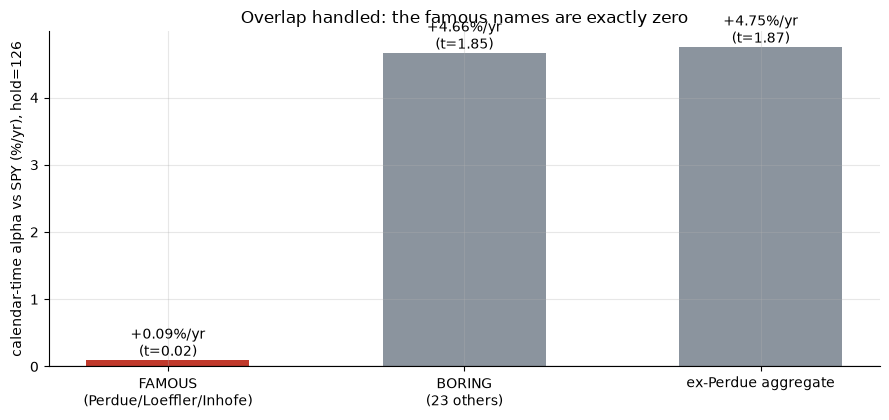

FAMOUS (Perdue/Loeffler/Inhofe)    alpha +0.09%/yr  NW t = +0.02
BORING (23 others)                 alpha +4.66%/yr  NW t = +1.85
ex-Perdue aggregate                alpha +4.75%/yr  NW t = +1.87


In [5]:
if HAVE_REAL:
    fam = st.calendar_time(PX, SPY, EV[EV['famous']], hold=126)
    bor = st.calendar_time(PX, SPY, EV[~EV['famous']], hold=126)
    exP = st.calendar_time(PX, SPY, EV[EV['senator'] != 'David A Perdue , Jr'], hold=126)
    trio = [('FAMOUS (Perdue/Loeffler/Inhofe)', fam['alpha_ann_pct'], fam['nw_t']),
            ('BORING (23 others)', bor['alpha_ann_pct'], bor['nw_t']),
            ('ex-Perdue aggregate', exP['alpha_ann_pct'], exP['nw_t'])]
else:
    trio = [('FAMOUS (Perdue/Loeffler/Inhofe)', *R['famous_ct']),
            ('BORING (23 others)', *R['boring_ct']),
            ('ex-Perdue aggregate', *R['exPerdue_ct'])]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
cols = [RED, GREY, GREY]
ax.bar([t[0].replace(' (', '\n(') for t in trio], [t[1] for t in trio], color=cols, width=.55)
for i, t in enumerate(trio): ax.annotate(f'{t[1]:+.2f}%/yr\n(t={t[2]:.2f})', (i, t[1]), ha='center', va='bottom')
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('calendar-time alpha vs SPY (%/yr), hold=126')
ax.set_title('Overlap handled: the famous names are exactly zero')
plt.tight_layout(); plt.show()
for t in trio: print(f'{t[0]:34s} alpha {t[1]:+.2f}%/yr  NW t = {t[2]:+.2f}')

> 💡 In plain words: the meme's star exhibit (famous pooled Welch t = 4.6) is the textbook failure mode this desk exists to catch — a significant-looking t built on non-independent observations. Handled honestly, the famous names earn **+0.09%/yr (t = 0.02)**. **BUSTED**, with the artifact dissected rather than just asserted.

### 4e · Costs (formality) and the faithful-engine control

Costs barely move a 126-td-hold portfolio (2 legs amortised over six months) — the problem was never the friction. The synthetic control proves the machinery: a null world (no planted drift, 20 seeds) must stay flat; a planted +6 bps/day post-disclosure drift must light up.

costs at hold=126 (frozen from results.md):
   0.0 bps one-way: net alpha +3.72%/yr  NW t = +1.11
   5.0 bps one-way: net alpha +3.52%/yr  NW t = +1.05
  10.0 bps one-way: net alpha +3.32%/yr  NW t = +0.99


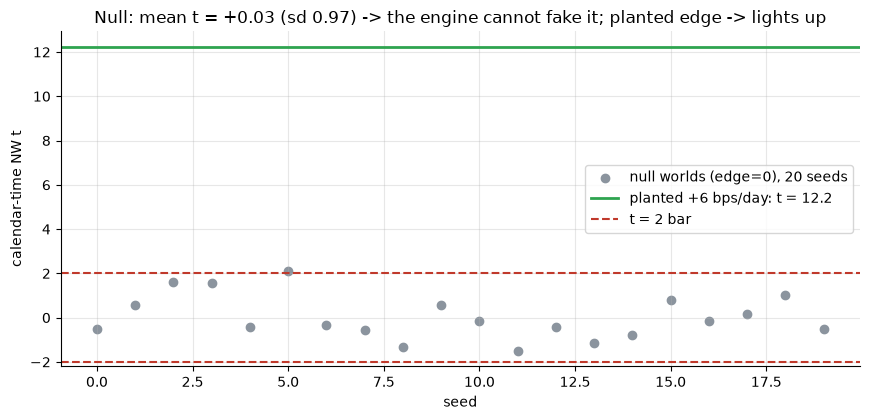

null 20 seeds: mean t +0.03, sd 0.97, max|t| 2.10
planted edge: alpha +27.37%/yr, NW t +12.25


In [6]:
print('costs at hold=126 (frozen from results.md):')
for cb, na, t in R['costs']: print(f'  {cb:>4.1f} bps one-way: net alpha {na:+.2f}%/yr  NW t = {t:+.2f}')
ts = []
for s in range(20):
    spx, sspy, sev = data.synthetic_world(edge_daily=0.0, seed=629 + s)
    ts.append(st.calendar_time(spx, sspy, sev, hold=126)['nw_t'])
spx, sspy, sev = data.synthetic_world(edge_daily=0.0006, seed=629)
rp = st.calendar_time(spx, sspy, sev, hold=126)
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.scatter(range(20), ts, c=GREY, label='null worlds (edge=0), 20 seeds')
ax.axhline(rp['nw_t'], c=GREEN, lw=2, label=f'planted +6 bps/day: t = {rp["nw_t"]:.1f}')
ax.axhline(2, ls='--', c=RED, label='t = 2 bar'); ax.axhline(-2, ls='--', c=RED)
ax.set_xlabel('seed'); ax.set_ylabel('calendar-time NW t')
ax.set_title(f'Null: mean t = {np.mean(ts):+.2f} (sd {np.std(ts):.2f}) -> the engine cannot fake it; planted edge -> lights up')
ax.legend(loc='center right'); plt.tight_layout(); plt.show()
print(f'null 20 seeds: mean t {np.mean(ts):+.2f}, sd {np.std(ts):.2f}, max|t| {np.max(np.abs(ts)):.2f}')
print(f'planted edge: alpha {rp["alpha_ann_pct"]:+.2f}%/yr, NW t {rp["nw_t"]:+.2f}')

> 💡 In plain words: in 20 senator-free worlds the engine reads **t ≈ 0** (mean +0.03, sd 0.97); plant a real post-disclosure drift and it screams (**t = 12.2**). So when it reads t ≤ 1.11 on the real senators, that's the tape talking, not a blind instrument. *(Machinery proof only — never cited as market evidence.)*

## 5 · The verdict

- **Signal `NONE`** — calendar-time alpha -0.01 / +3.72 / +2.50 %/yr (3/6/12-mo holds) with **NW t = -0.00 / +1.11 / +0.89**; the random-dates placebo absorbs the entire drift (+0.41%/yr, +0.49σ). The pooled 12-mo +4.87% (naive t = 6.35) is overlap pseudo-replication. Survivor-tilted panel (~20% of events lost with dead tickers) *favours* the claim and it still fails. Matches Eggers-Hainmueller (2013) and Belmont et al. (2022); Ziobrowski's 1990s transaction-date alpha does not survive to the disclosed era.
- **Tradability `MIRAGE`** — median 19-day staleness, zero measurable timing information, net +3.32%/yr at 10 bps (t = 0.99). Copy-trading apps sell the stock list, not an edge.
- **Famous names beat? `BUSTED`** — famous calendar-time alpha **+0.09%/yr (t = 0.02)** vs boring +4.66%/yr (t = 1.85); the meme's Welch t = 4.6 is a clustering artifact of one senator's overlapping buys.

## 6 · Going further

- **Scope is data-bound.** Senate only, purchases only, 2015 → March 2021 (the scraper's death). The House tape (Pelosi-era memes), options PTRs, and 2021+ Senate filings are open extensions — House Stock Watcher / Quiver / Capitol Trades carry them.
- **Committee-matched trades** (senator buys a stock overseen by their committee) is the sharpest remaining hypothesis — it needs a committee-assignment table joined to tickers' sectors; the event engine here takes any extra event column.
- **Sales and the Burr trade.** February 2020's infamous dumps are *sales*; a symmetric study needs short-window CARs around the transaction (not disclosure) date and a very careful selection story.
- **The structural sibling** is [263-insider-buying](../../263-insider-buying/) — Form 4 corporate insiders, where the law, the information set and the literature are all different (and stronger).

*The reproducible core is offline and deterministic; the verdict statistic is the calendar-time Newey-West t at the disclosure-date entry, with a 20-seed random-dates placebo separating timing from stock list. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*